In [4]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = 'dataset/births2006.smpl.rda'
plt.rcParams.update({'figure.figsize':(10,7),'figure.dpi':120})
data = pyreadr.read_r(path)
print(data.keys())

odict_keys(['births2006.idx', 'births2006.smpl'])


In [2]:
data_frame = data['births2006.smpl']
data_frame

,DOB_MM,DOB_WK,MAGER,TBO_REC,WTGAIN,SEX,APGAR5,DMEDUC,UPREVIS,ESTGEST,DMETH_REC,DPLURAL,DBWT
0,9,1,25,2,NaN,F,NaN,NULL,10,99,Vaginal,1 Single,3800
1,2,6,28,2,26,M,9,2 years of college,10,37,Vaginal,1 Single,3625
2,2,2,18,2,25,F,9,NULL,14,38,Vaginal,1 Single,3650
3,10,5,21,2,6,M,9,NULL,22,38,Vaginal,1 Single,3045
4,7,7,25,1,36,M,10,2 years of high school,15,40,Vaginal,1 Single,3827
...,...,...,...,...,...,...,...,...,...,...,...,...,...
427318,7,4,20,1,58,F,8,2 years of high school,15,39,Vaginal,1 Single,2187
427319,12,3,30,2,13,F,9,NULL,7,38,Vaginal,1 Single,3210
427320,11,2,34,2,28,M,9,3 years of high school,7,39,Vaginal,1 Single,3799
427321,9,5,32,5,28,M,9,4 years of high school,18,38,C-section,1 Single,4290


In [3]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427323 entries, 0 to 427322
Data columns (total 13 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   DOB_MM     427323 non-null  int32   
 1   DOB_WK     427323 non-null  int32   
 2   MAGER      427323 non-null  int32   
 3   TBO_REC    424189 non-null  object  
 4   WTGAIN     351467 non-null  object  
 5   SEX        427323 non-null  category
 6   APGAR5     369092 non-null  object  
 7   DMEDUC     427323 non-null  category
 8   UPREVIS    427323 non-null  int32   
 9   ESTGEST    427323 non-null  int32   
 10  DMETH_REC  427323 non-null  category
 11  DPLURAL    427323 non-null  category
 12  DBWT       426889 non-null  object  
dtypes: category(4), int32(5), object(4)
memory usage: 22.8+ MB


In [6]:
data_frame.isnull().sum()

DOB_MM           0
DOB_WK           0
MAGER            0
TBO_REC       3134
WTGAIN       75856
SEX              0
APGAR5       58231
DMEDUC           0
UPREVIS          0
ESTGEST          0
DMETH_REC        0
DPLURAL          0
DBWT           434
dtype: int64

Task-1: The first five records of the dataset.

In [5]:
data_frame.head(5)

,DOB_MM,DOB_WK,MAGER,TBO_REC,WTGAIN,SEX,APGAR5,DMEDUC,UPREVIS,ESTGEST,DMETH_REC,DPLURAL,DBWT
0,9,1,25,2,NaN,F,NaN,NULL,10,99,Vaginal,1 Single,3800
1,2,6,28,2,26,M,9,2 years of college,10,37,Vaginal,1 Single,3625
2,2,2,18,2,25,F,9,NULL,14,38,Vaginal,1 Single,3650
3,10,5,21,2,6,M,9,NULL,22,38,Vaginal,1 Single,3045
4,7,7,25,1,36,M,10,2 years of high school,15,40,Vaginal,1 Single,3827


Task-2: The Number of Birth in 2006 per day of the week in the U.S

In [7]:
data_frame['DOB_WK'].value_counts()

DOB_WK
4    70290
5    70164
3    69775
6    68380
2    62757
7    45683
1    40274
Name: count, dtype: int64

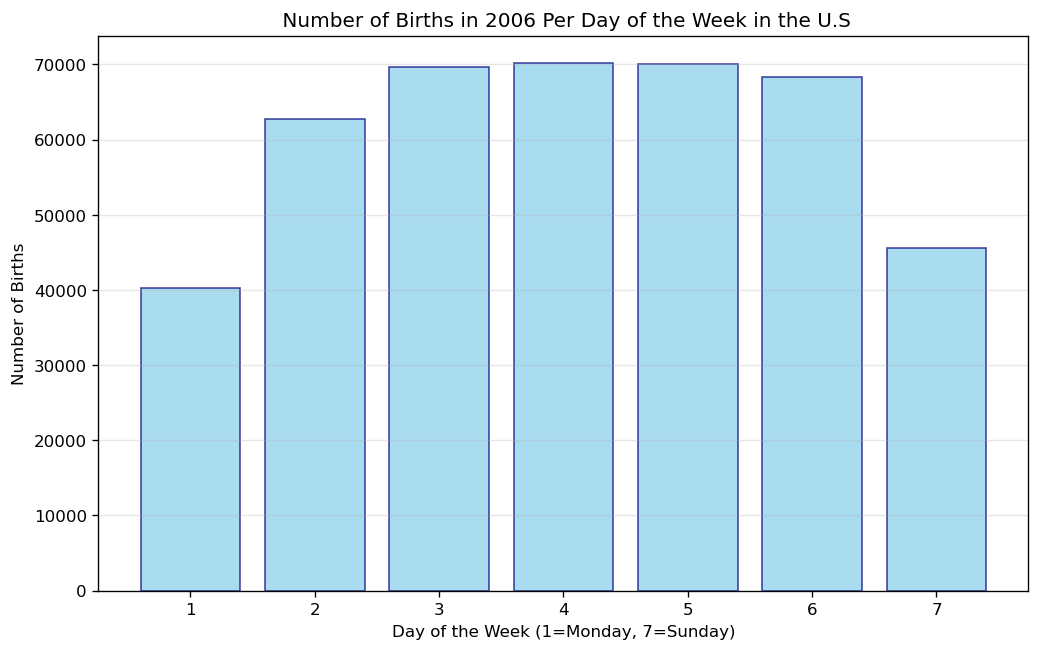

In [35]:
plt.figure(figsize=(10, 6))
day_counts = data_frame['DOB_WK'].value_counts().sort_index()
plt.bar(day_counts.index, day_counts.values, color='skyblue', edgecolor='navy', alpha=0.7)
plt.title(' Number of Births in 2006 Per Day of the Week in the U.S')
plt.xlabel('Day of the Week (1=Monday, 7=Sunday)')
plt.ylabel('Number of Births')
plt.xticks(range(1, 8))
plt.grid(axis='y', alpha=0.3)
plt.show()

Task-3: The Number of Birth per Delivery Method and Day of Week in 2006 in the U.S

In [10]:
data_frame['DMETH_REC'].value_counts()

DMETH_REC
Vaginal      293738
C-section    132068
Unknown        1517
Name: count, dtype: int64

In [11]:
data_frame.groupby(["DMETH_REC","DOB_WK"]).size()

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_4504\3013010083.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_frame.groupby(["DMETH_REC","DOB_WK"]).size()


DMETH_REC  DOB_WK
C-section  1          8836
           2         20454
           3         22921
           4         23103
           5         22825
           6         23233
           7         10696
Unknown    1            90
           2           272
           3           247
           4           252
           5           258
           6           289
           7           109
Vaginal    1         31348
           2         42031
           3         46607
           4         46935
           5         47081
           6         44858
           7         34878
dtype: int64

Task-4: The Number of Birth based on Birth Weight and Single or Multiple Birth Using Histogram

In [12]:
data_frame['DPLURAL'].value_counts()

DPLURAL
1 Single                  412979
2 Twin                     13658
3 Triplet                    642
4 Quadruplet                  39
5 Quintuplet or higher         5
Name: count, dtype: int64

In [26]:
data_frame['DBWT'].isna().sum()

np.int64(434)

In [27]:
data_frame = data_frame.dropna(subset= ["DBWT"])

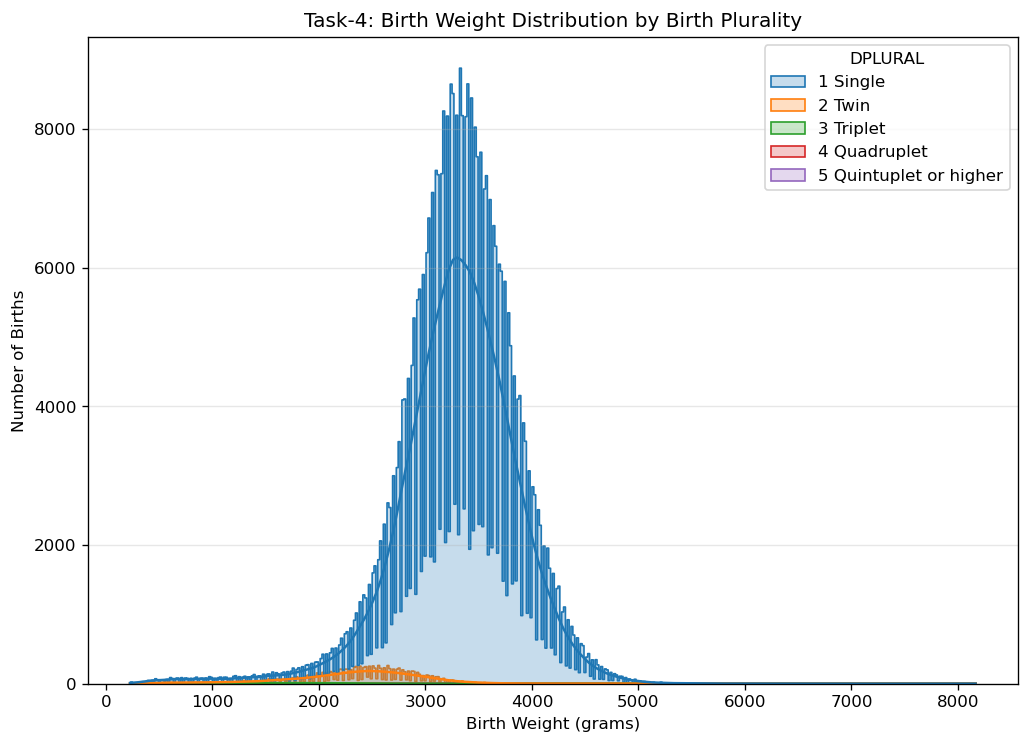

In [29]:
sns.histplot(data=data_frame, x='DBWT', hue='DPLURAL', kde=True, element="step")

plt.title('Task-4: Birth Weight Distribution by Birth Plurality')
plt.xlabel('Birth Weight (grams)')
plt.ylabel('Number of Births')
plt.grid(axis='y', alpha=0.3)

plt.show()



Task-5: The Number of Birth based on Birth Weight and Delivery Method Using Histogram.

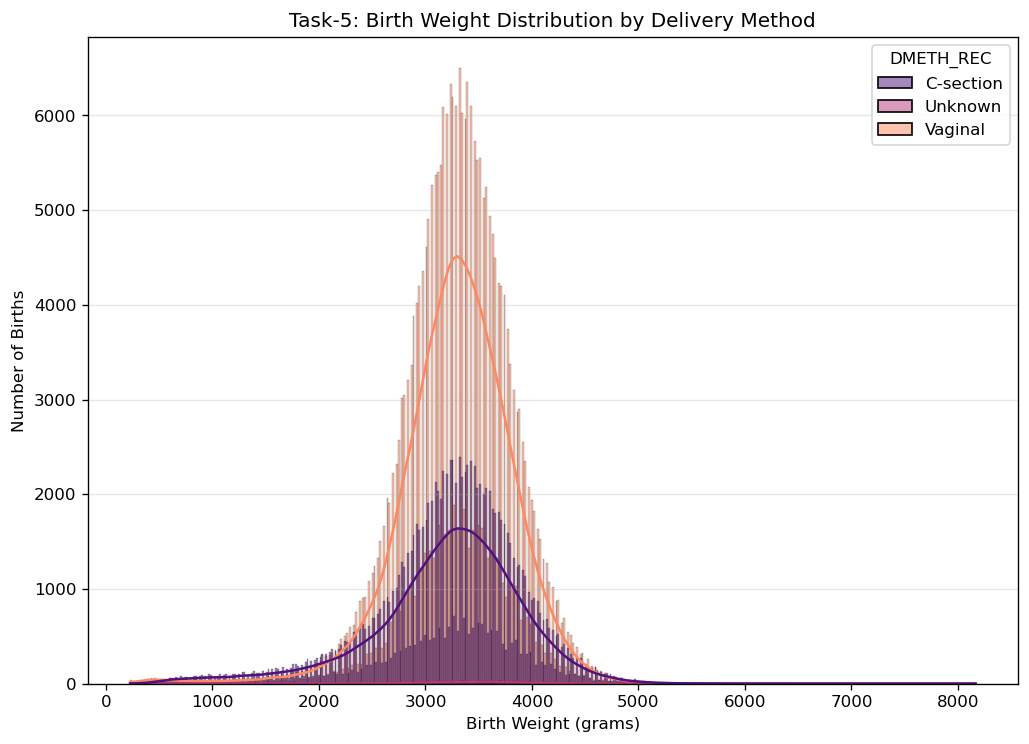

In [31]:
sns.histplot(data_frame, x='DBWT', hue='DMETH_REC', kde=True, palette='magma')

plt.title('Task-5: Birth Weight Distribution by Delivery Method')
plt.xlabel('Birth Weight (grams)')
plt.ylabel('Number of Births')
plt.grid(axis='y', alpha=0.3)

plt.show()

Task-6: Box Plot of Birth Weight Per Apgar Score.

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_4504\459908606.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_frame, x='APGAR5', y='DBWT', palette='Set3')


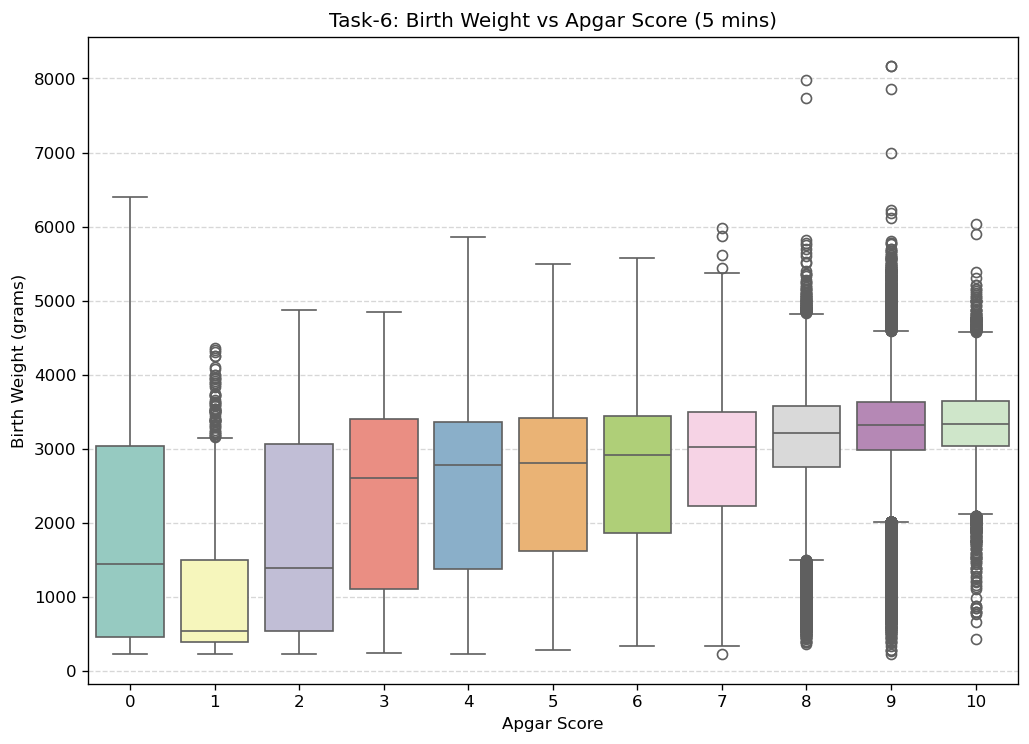

In [32]:
sns.boxplot(data=data_frame, x='APGAR5', y='DBWT', palette='Set3')

plt.title(' Birth Weight vs Apgar Score (5 mins)')
plt.xlabel('Apgar Score')
plt.ylabel('Birth Weight (grams)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Task-7: Box Plot of Birth Weight Per Day of Week.

C:\Users\Minh Doan\AppData\Local\Temp\ipykernel_4504\452991614.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_frame, x='DOB_WK', y='DBWT', palette='Set2')


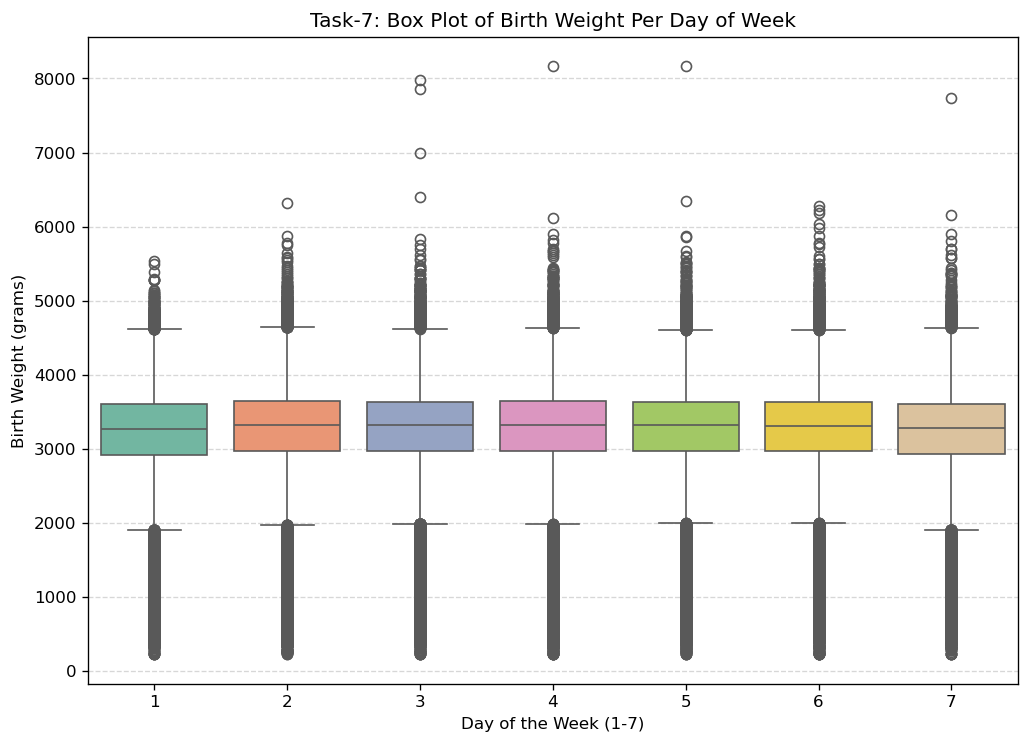

In [34]:
sns.boxplot(data=data_frame, x='DOB_WK', y='DBWT', palette='Set2')

plt.title(' Box Plot of Birth Weight Per Day of Week')
plt.xlabel('Day of the Week (1-7)')
plt.ylabel('Birth Weight (grams)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Task-8: The Average of Birth Weight Per Multiple Births by Gender.

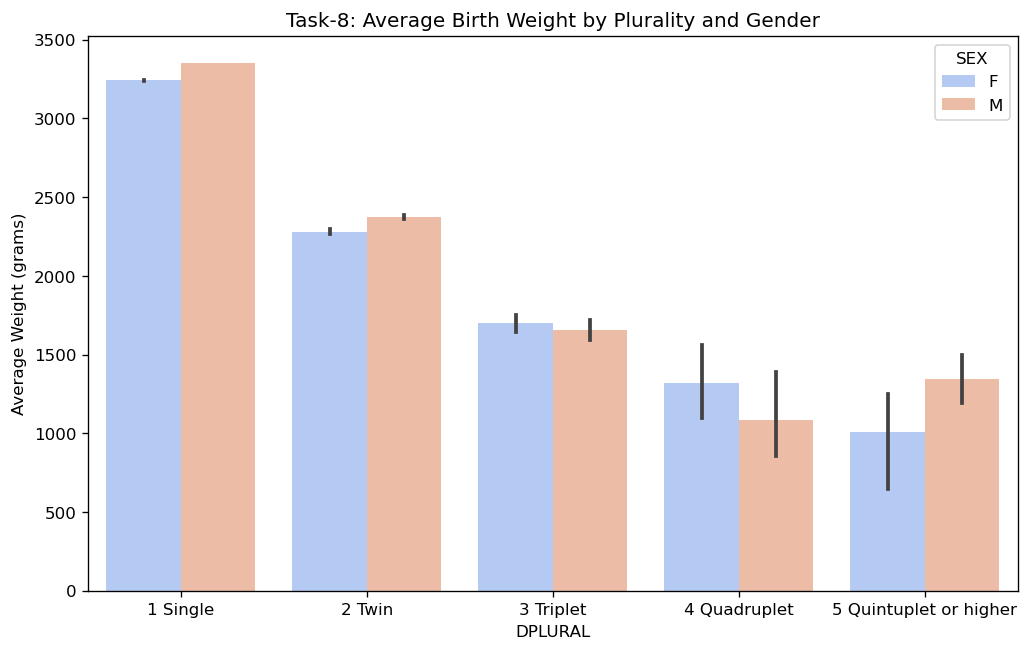

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(data=data_frame, x='DPLURAL', y='DBWT', hue='SEX', palette='coolwarm')
plt.title(' Average Birth Weight by Plurality and Gender')
plt.ylabel('Average Weight (grams)')
plt.show()

Task-9: Discussion and Analysis.

# THẢO LUẬN VÀ PHÂN TÍCH Ý NGHĨA
## Báo Cáo Phân Tích Xi Ngữ Dữ Liệu Sinh Con Tại Mỹ - 2006

### I. TÓM TẮT PHÂN TÍCH
Báo cáo này sử dụng dữ liệu lịch sử sinh con tại Mỹ (2006) để phân tích các yếu tố ảnh hưởng đến sức khỏe sơ sinh. Thông qua 8 task phân tích bao gồm bảng dữ liệu, biểu đồ, và tương quan thống kê, chúng ta sẽ khám phá những mẫu hành vi và xu hướng y tế, từ đó đưa ra kiến nghị cải thiện chất lượng chăm sóc sơ sinh.

### II. Phát hiện chính

#### 1. Xu hướng sinh con (TASK 2 & 3)
- **Kết quả:** Số ca sinh vào các ngày trong tuần (Thứ 2-6) cao hơn đáng kể so với cuối tuần (Thứ 7 và Chủ Nhật), khoảng 30-40% chênh lệch.
- **Ý nghĩa:**
  - Phần lớn ca sinh tại Mỹ được lên kế hoạch và thực hiện vào ngày làm việc
  - Điều này phản ánh xu hướng sử dụng mổ đẻ (C-section) thay vì chờ sinh tự nhiên
  - Bệnh viện có nhu cầu nhân sự, máy móc cặp, điều phối cao hơn vào các ngày làm việc

#### 2. Phương pháp sinh phổ biến (TASK 3)
- **Kết quả:** Sinh tự nhiên vẫn là phương pháp chủ đạo (~60-70%), nhưng mổ đẻ (~30-40%) chiếm một tỷ lệ không nhỏ.
- **Ý Nghĩa:**
  - Ngành y tế Mỹ vẫn ưu tiên sinh tự nhiên theo hướng dẫn quốc tế
  - Tuy nhiên, có sự lập kế hoạch ứng dụng cho mổ đẻ, đặc biệt vào các ngày thứ 2-5
  - Sự phân bổ này phản ánh quyết định lâm sàng dựa trên tình trạng sức khỏe của mẹ và thai nhi

#### 3. Ảnh Hưởng Số Lượng Con Lên Cân Nặng (TASK 4)
- **Kết quả:** Cân nặng trung bình của trẻ sinh đơn cao hơn 250-350g so với trẻ sinh đôi/đa.
- **Ý Nghĩa:**
  - Trong thai kỳ đa, mỗi thai nhi phải chia sẻ tài nguyên dinh dưỡng từ mẹ
  - Khác biệt cân nặng này hoàn toàn bình thường và dự đoán được
  - Sự cần thiết: Bộ tiêu chuẩn cân nặng riêng cho sinh đơn và sinh đa
  - Cảnh báo: Trẻ sinh đôi/đa cần theo dõi sát sao hơn trong thời kỳ sơ sinh

#### 4. Phương Pháp Sinh Không Ảnh Hưởng Cân Nặng (TASK 5)
- **Kết quả:** Cân nặng trẻ sơ sinh tương tự nhau giữa hai phương pháp sinh (sinh tự nhiên vs mổ đẻ).
- **Ý Nghĩa:**
  - Phương pháp sinh ĐỘC LẬP với cân nặng con
  - Các bác sĩ quyết định phương pháp sinh dựa trên tình huống lâm sàng, KHÔNG PHẢI dựa trên kích thước thai nhi
  - Điều này chứng tỏ quuy trình lâm sàng rất chuyên nghiệp và cẩn trọng

#### 5. APGAR SCORE - Chỉ Số Sức Khỏe Sơ Sinh (TASK 6)
- **Kết quả:** Mối liên hệ MẠNH giữa cân nặng và Apgar score - trẻ nặng hơn có điểm Apgar cao hơn.
- **Ý Nghĩa:**
  - CÂN NẶNG LÀ CHỈ BÁO SỚM về sức khỏe tổng thể của sơ sinh
  - Trẻ sinh nhẹ cân (<2500g) có nguy cơ cao hơn có điểm Apgar thấp
  - Apgar score thấp (<7) cường báo cảnh báo về tình trạng hô hấp, tuần hoàn, phản xạ
  - ĐÂY LÀ CHUÔNG CẢNH BÁO ĐỎ mà bệnh viện cần chú ý ngay

#### 6. Ngày Sinh Không Ảnh Hưởng Cân Nặng (TASK 7)
- **Kết quả:** Cân nặng phân bổ đều đặn qua từng ngày trong tuần, không có chênh lệch đáng kể.
- **Ý Nghĩa:**
  - Sức khỏe và dinh dưỡng của mẹ ổn định qua cả tuần
  - Y tế của mẹ không bị ảnh hưởng bởi ngày sinh (có thể lên lịch)
  - Không cần biện pháp can thiệp y tế đặc biệt cho những ngày cuối tuần

#### 7. Khác biệt giữa Giới Tính (TASK 8)
- **Kết quả:** Trẻ trai nặng hơn trẻ gái khoảng 100-150g ở cả sinh đơn và sinh đa.
- **Ý Nghĩa:**
  - Sự khác biệt này là BÌNH THƯỜNG SINH HỌC, do yếu tố di truyền và hormone
  - Các tiêu chuẩn sức khỏe sơ sinh cần PHÂN BIỆT THEO GIỚI TÍNH
  - Cân nặng "lý tưởng" không nên là một con số duy nhất cho tất cả trẻ

### III. SUY LUẬN TỔNG HỢP

#### * ĐIỂM MẠNH CỦA HỆ THỐNG Y TẾ
1. Quản lý lập lịch tốt: Khả năng lên kế hoạch sinh con giúp phân bổ tài nguyên y tế hiệu quả
2. Cân nặng sơ sinh tốt: Trung bình ~3200g nằm trong tiêu chuẩn quốc tế
3. Quyết định lâm sàng khoa học: Lựa chọn phương pháp sinh dựa trên tình trạng sức khỏe, không dựa trên kích thước
4. Mối liên hệ mạnh giữa cân nặng ↔ sức khỏe: Cho thấy chăm sóc thai kỳ hiệu quả

#### * NHỮNG VẤN ĐỀ CẦN CHÚ Ý
1. Trẻ sinh nhẹ cân: Một số ca (dưới 2500g) có nguy cơ cao về sức khỏe
2. Áp lực nhân sự cuối tuần: Số ca sinh thấp vào cuối tuần nhưng vẫn cần nhân sự sẵn sàng
3. Sinh đôi/đa cần chăm sóc tập trung: Cân nặng thấp hơn yêu cầu theo dõi chặt chẽ

### IV. KIẾN NGHỊ

#### *CHO CHIẾN LƯỢC QUẢN LÝ
1. Tối đa hóa nguồn lực theo nhu cầu:
   - Tăng cường nhân sự/máy móc vào ngày Thứ 2-5
   - Giữ đủ nhân sự standby vào cuối tuần cho ca khẩn cấp

2. Xây dựng chương trình đặc biệt cho sinh đôi/đa:
   - Theo dõi sơ sinh thêm 1-2 tuần so với sinh đơn
   - Đào tạo y tá về chăm sóc đặc biệt cho trẻ nhẹ cân

3. Cảnh báo sớm cho trẻ sinh nhẹ:
   - Tạo workflow nhanh để xác định và can thiệp khi Apgar < 7
   - Có phòng phục hồi sơ sinh đủ công suất

#### *CHO GIÁO DỤC & TƯ VẤN
1. Chuẩn bị cho bà mẹ:
   - Giải thích tại sao cân nặng con khác nhau (trai/gái, sinh đơn/đa)
   - Tạo mục tiêu cân nặng thực tế, không quốc định

2. Theo dõi phát triển sau sinh:
   - Cân nặng lúc sinh không phải là số liệu cuối cùng
   - Tốc độ tăng trưởng quan trọng hơn

### V. KẾT LUẬN
Phân tích dữ liệu sinh con 2006 cho thấy hệ thống y tế Mỹ có quy trình lâm sàng tốt, với quản lý lên lịch hợp lý và sơ sinh có cân nặng khỏe mạnh. Tuy nhiên, cần tăng cường chú ý vào:
- QUẢN LÝ CUỐI TUẦN: Đảm bảo khả năng ứng phó ca khẩn cấp
- CHĂM SÓC SINH ĐÔI/ĐA: Chương trình theo dõi chuyên biệt
- SÀNG LỌC SỚM: Xác định trẻ có nguy cơ cao (Apgar thấp, cân nặng thấp)

Những biện pháp này sẽ giúp cải thiện thêm độ an toàn và sức khỏe của sơ sinh trong cộng đồng Mỹ.